In [30]:
import pandas as pd
from pathlib import Path

cwd = Path.cwd()
csv_path = cwd / 'flat_modes_manual_data.csv'

df_raw = pd.read_csv(csv_path)

df = df_raw.copy()
df.columns = ['t', 'ax', 'ff', 'upper', 'lower']
df['diff'] = df['upper'] - df['lower']
df['mean'] = (df['upper'] + df['lower']) / 2

df


,t,ax,ff,upper,lower,diff,mean
0,100,250,0.78,1.74,1.53,0.21,1.635
1,100,300,0.78,1.57,1.37,0.20,1.470
2,100,300,0.80,1.55,1.36,0.19,1.455
3,40,300,0.78,1.84,1.67,0.17,1.755
4,40,300,0.80,1.82,1.66,0.16,1.740
5,40,300,0.82,1.80,1.65,0.15,1.725
6,40,350,0.78,1.74,1.55,0.19,1.645
7,40,350,0.80,1.72,1.55,0.17,1.635
8,40,350,0.82,1.70,1.54,0.16,1.620
9,50,300,0.78,1.78,1.60,0.18,1.690


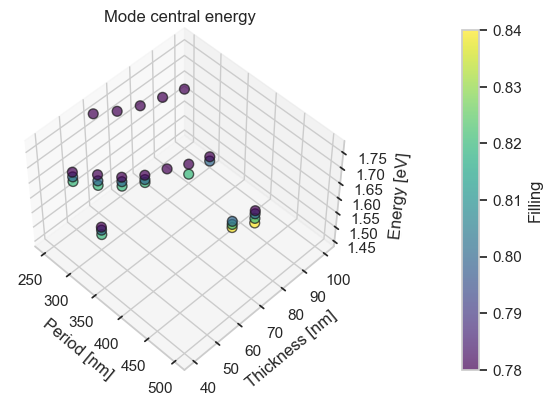

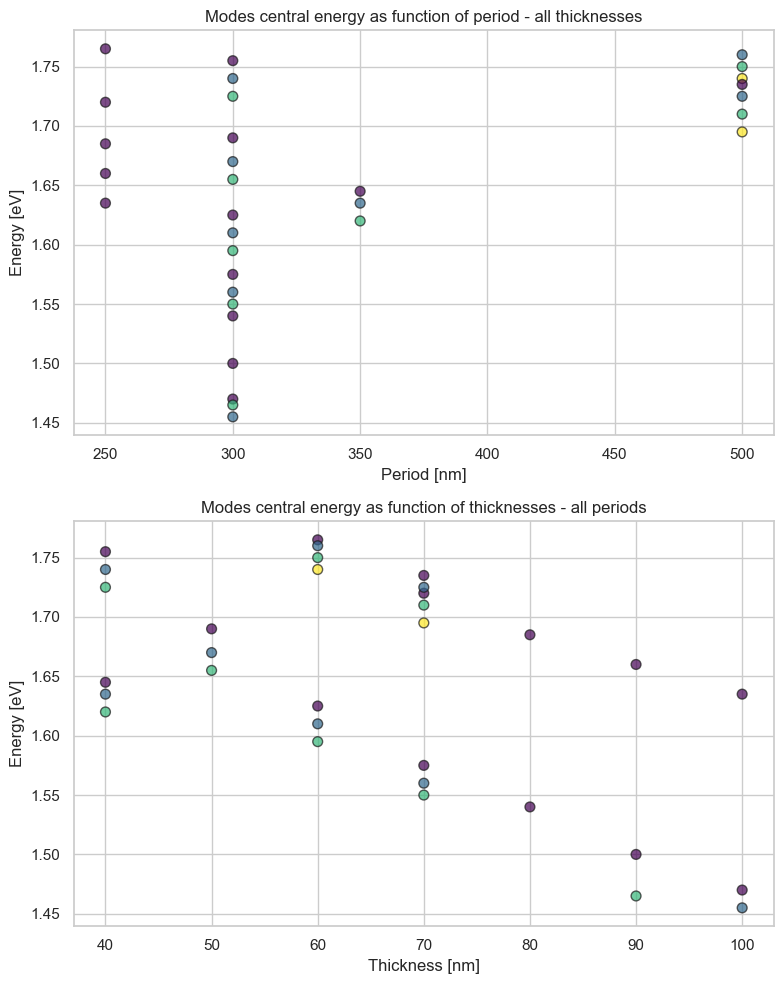

In [31]:
import matplotlib.pyplot as plt


periods = df['ax'].to_numpy()
thicknesses = df['t'].to_numpy()
filling = df['ff'].to_numpy()
mean_energy = df['mean'].to_numpy()
diff_energy = df['diff'].to_numpy()

title = 'Mode central energy'

# Create a figure with 2 rows and 1 column for the 3D plot above and 2D plots below
fig = plt.figure(figsize=(12, 15))

p_lab='Period [nm]'
t_lab='Thickness [nm]'
e_lab='Energy [eV]'
f_lab = 'Filling'

# 3D Plot
ax1 = fig.add_subplot(311, projection='3d')
scatter1 = ax1.scatter(periods, thicknesses, mean_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
cbar = fig.colorbar(scatter1)
cbar.set_label(f_lab)
ax1.set_xlabel(p_lab)
ax1.set_ylabel(t_lab)
ax1.set_zlabel(e_lab)
ax1.set_title(title)
ax1.view_init(elev=50, azim=-45)
plt.subplots_adjust(right=2)
#ax1.invert_yaxis()
plt.show()

fig = plt.figure(figsize=(8, 10))
# 2D plot for Period vs Energy
ax2, ax3 = fig.subplots(nrows=2, ncols=1, sharex=False, sharey=False)

scatter2 = ax2.scatter(periods, mean_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax2.set_xlabel(p_lab)
ax2.set_ylabel(e_lab)
ax2.set_title("Modes central energy as function of period - all thicknesses")

# 2D plot for Thickness vs Energy
scatter3 = ax3.scatter(thicknesses, mean_energy, c=filling, cmap='viridis', marker='o', s=50, edgecolor='k', alpha=0.7)
ax3.set_xlabel(t_lab)
ax3.set_ylabel(e_lab)
ax3.set_title("Modes central energy as function of thicknesses - all periods")
# ax3.invert_xaxis()


# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()



<Figure size 1500x1000 with 0 Axes>

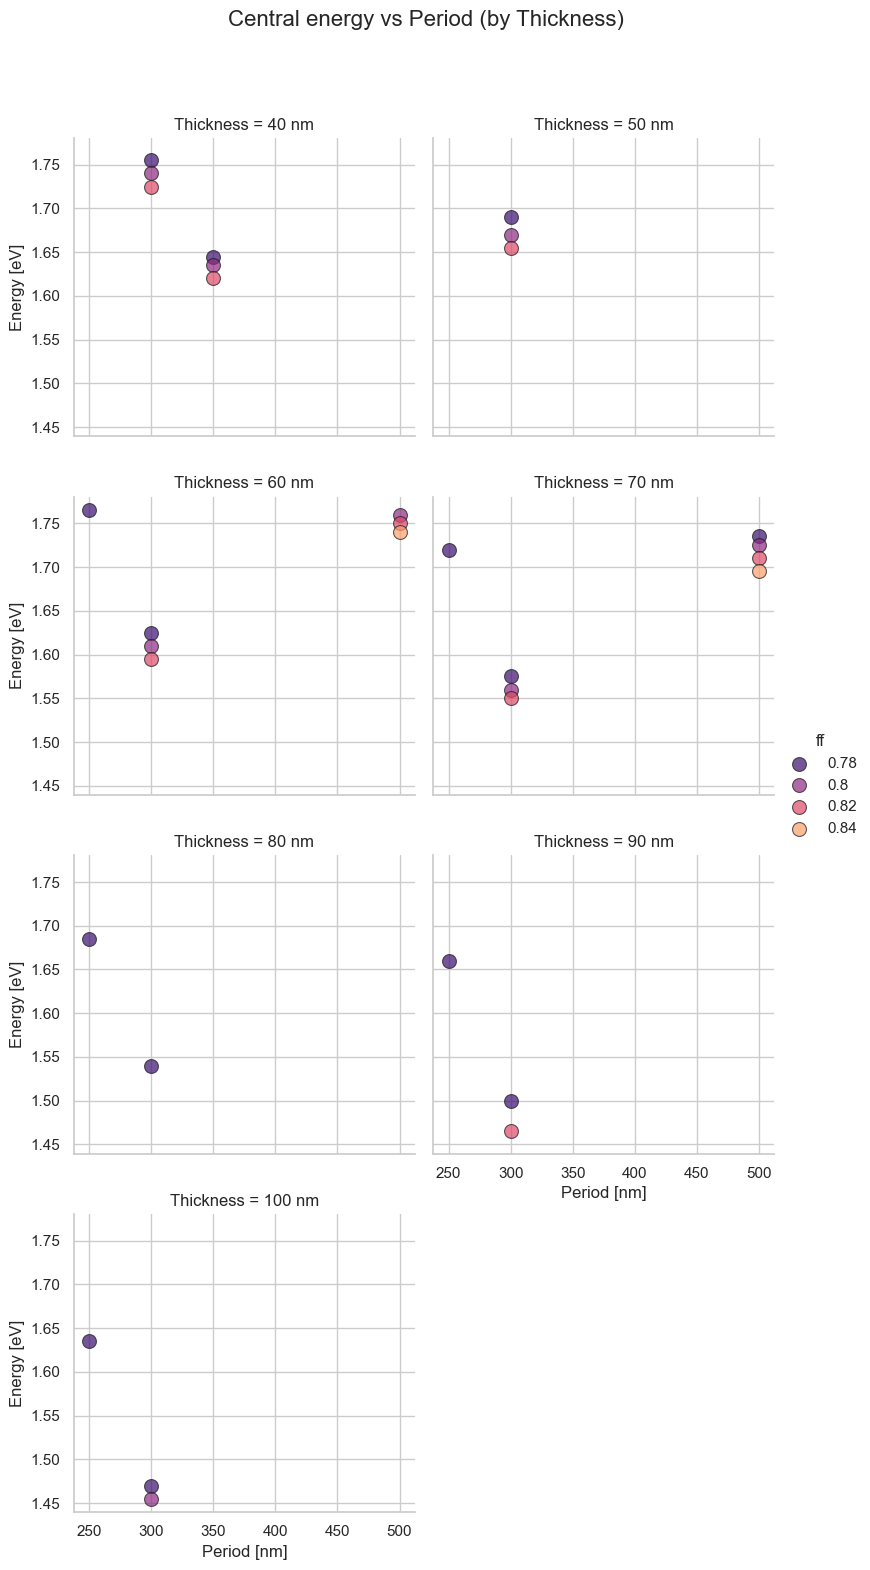

<Figure size 1500x1000 with 0 Axes>

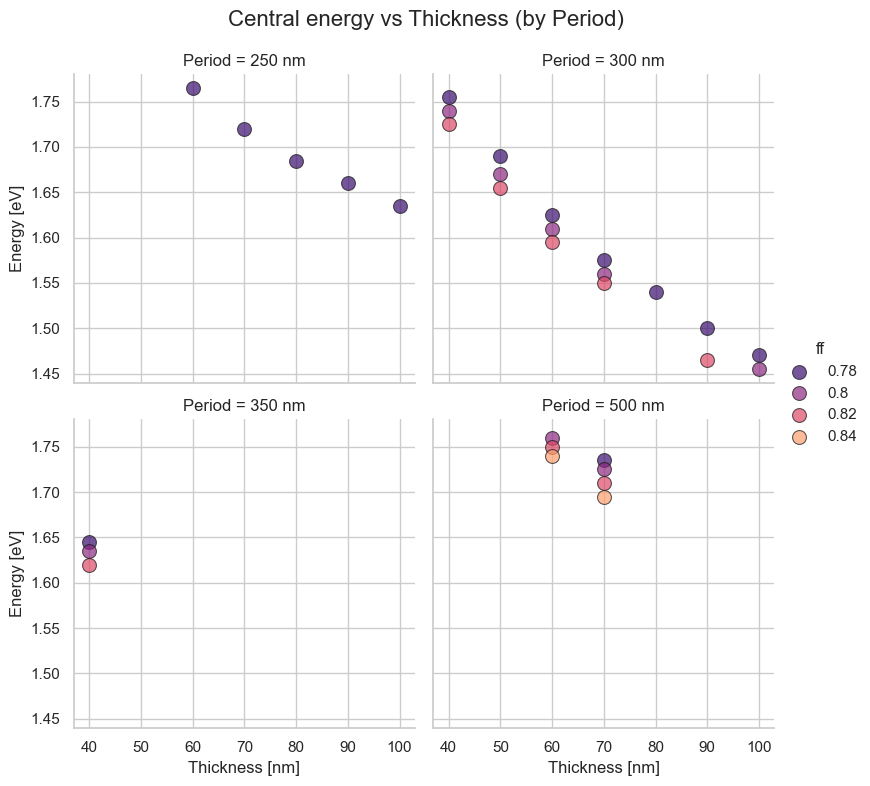

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the seaborn style
sns.set_theme(style="whitegrid")

# Create the figure for the 2D plots (Energy vs Period, with Thickness as separate plots)
fig1 = plt.figure(figsize=(15, 10))
g1 = sns.FacetGrid(
    data=df,
    col="t", 
    col_wrap=2, 
    height=4, 
    hue="ff", 
    palette="magma"
)
g1.map_dataframe(
    sns.scatterplot, 
    x="ax", 
    y="mean", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g1.set_axis_labels(p_lab, e_lab)
g1.set_titles(col_template="Thickness = {col_name} nm")
g1.add_legend()

# Display the Energy vs Period plot grid
plt.subplots_adjust(top=0.9)
g1.fig.suptitle('Central energy vs Period (by Thickness)', fontsize=16)
plt.show()

# Create the figure for the 2D plots (Energy vs Thickness, with Period as separate plots)
fig2 = plt.figure(figsize=(15, 10))
g2 = sns.FacetGrid(
    data=df,
    col="ax", 
    col_wrap=2, 
    height=4, 
    hue="ff", 
    palette="magma"
)
g2.map_dataframe(
    sns.scatterplot, 
    x="t", 
    y="mean", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g2.set_axis_labels(t_lab, e_lab)
g2.set_titles(col_template="Period = {col_name} nm")
g2.add_legend()

# Display the Energy vs Thickness plot grid
plt.subplots_adjust(top=0.9)
g2.fig.suptitle('Central energy vs Thickness (by Period)', fontsize=16)
plt.show()


<Figure size 1500x1000 with 0 Axes>

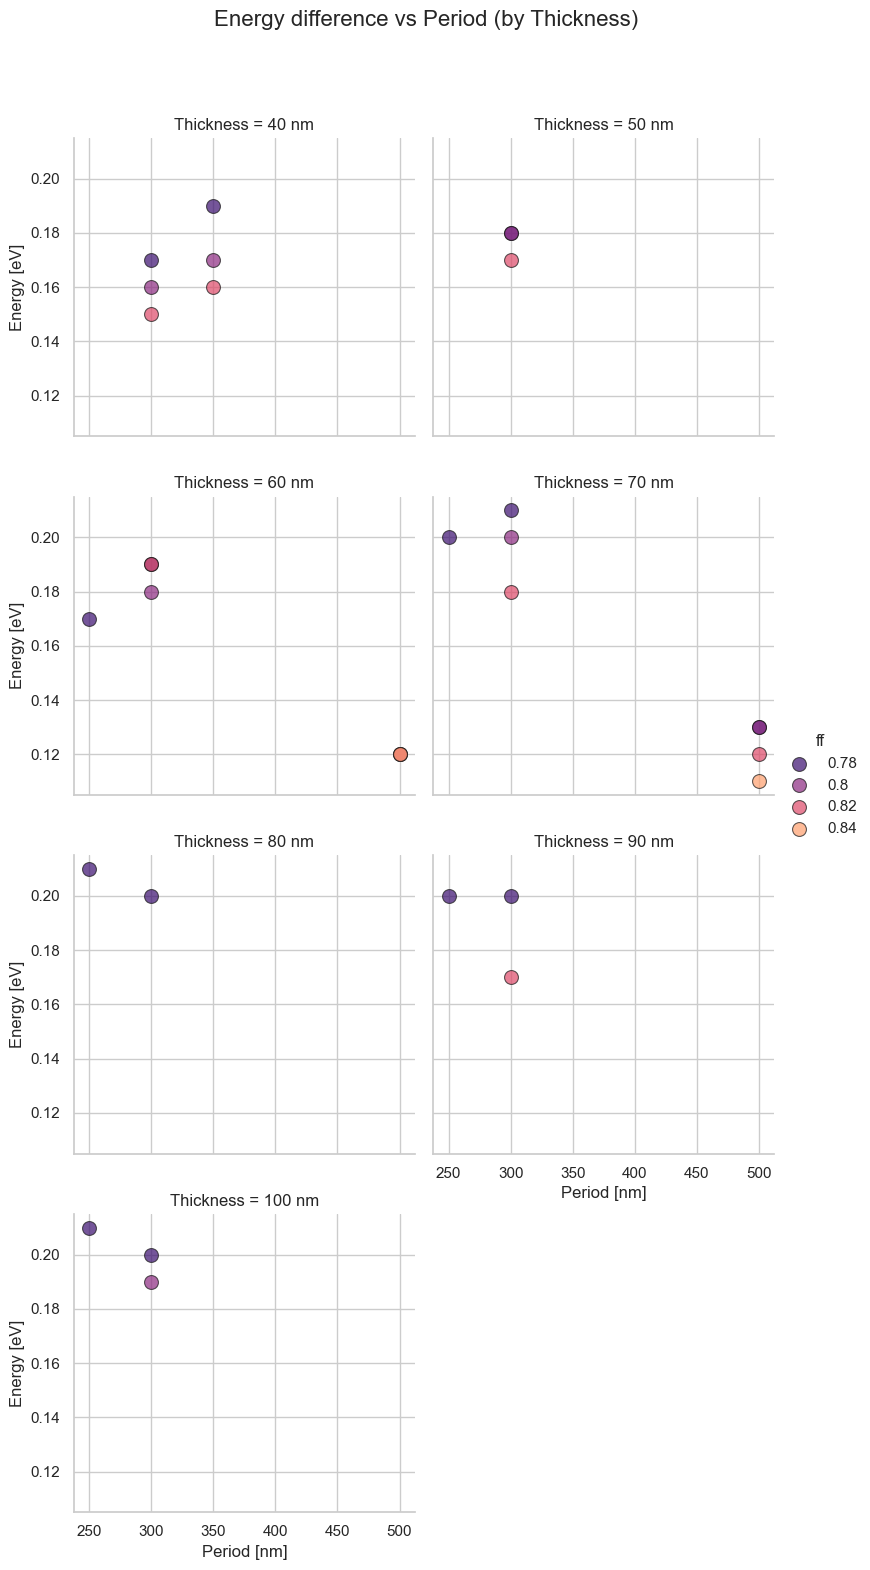

<Figure size 1500x1000 with 0 Axes>

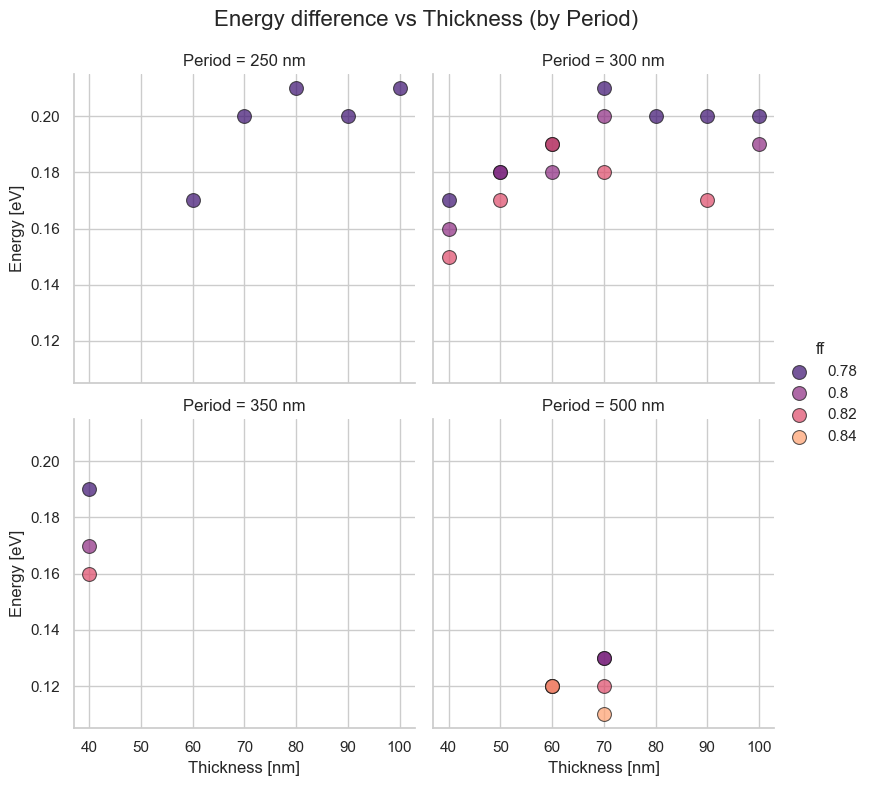

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the seaborn style
sns.set_theme(style="whitegrid")

# Create the figure for the 2D plots (Energy vs Period, with Thickness as separate plots)
fig1 = plt.figure(figsize=(15, 10))
g1 = sns.FacetGrid(
    data=df,
    col="t", 
    col_wrap=2, 
    height=4, 
    hue="ff", 
    palette="magma"
)
g1.map_dataframe(
    sns.scatterplot, 
    x="ax", 
    y="diff", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g1.set_axis_labels(p_lab, e_lab)
g1.set_titles(col_template="Thickness = {col_name} nm")
g1.add_legend()

# Display the Energy vs Period plot grid
plt.subplots_adjust(top=0.9)
g1.fig.suptitle('Energy difference vs Period (by Thickness)', fontsize=16)
plt.show()

# Create the figure for the 2D plots (Energy vs Thickness, with Period as separate plots)
fig2 = plt.figure(figsize=(15, 10))
g2 = sns.FacetGrid(
    data=df,
    col="ax", 
    col_wrap=2, 
    height=4, 
    hue="ff", 
    palette="magma"
)
g2.map_dataframe(
    sns.scatterplot, 
    x="t", 
    y="diff", 
    edgecolor='k', 
    s=100, 
    alpha=0.7
)
g2.set_axis_labels(t_lab, e_lab)
g2.set_titles(col_template="Period = {col_name} nm")
g2.add_legend()

# Display the Energy vs Thickness plot grid
plt.subplots_adjust(top=0.9)
g2.fig.suptitle('Energy difference vs Thickness (by Period)', fontsize=16)
plt.show()


In [34]:
print()